# День 7 — Анализ ошибок и мини-приложение

**Цель:** разобраться, на чём именно ошибается модель, и собрать демо.

Переиспользуемый код — в [`error_analysis.py`](error_analysis.py) и [`predictor.py`](predictor.py).

In [1]:
from compare_utils import (
    get_test_split, load_fine_tuned, load_baseline, load_tfidf,
    predict_fine_tuned, predict_baseline, predict_tfidf,
)
from tokenization_utils import load_tokenizer
from embeddings_utils import load_model

test_texts, test_labels = get_test_split()

model_ft, tokenizer = load_fine_tuned()
preds_ft = predict_fine_tuned(test_texts, model_ft, tokenizer)
y_pred_ft = [p['prediction'] for p in preds_ft]
probs_ft = [p['probabilities'] for p in preds_ft]

print(f'Тестовая выборка: {len(test_texts)}')

C:\Users\Vsevolod\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7003.98it/s]

Тестовая выборка: 600


## Задача 1: Анализ False Positive и False Negative

In [2]:
import pandas as pd

df_test = pd.DataFrame({
    'text': test_texts,
    'true_label': test_labels,
    'pred_label': y_pred_ft,
    'confidence': [p.max() for p in probs_ft],
})

errors = df_test[df_test['true_label'] != df_test['pred_label']]

# False Positives: предсказали positive (1), а было negative (0)
fp = errors[(errors['pred_label'] == 1) & (errors['true_label'] == 0)]
# False Negatives: предсказали negative (0), а было positive (1)
fn = errors[(errors['pred_label'] == 0) & (errors['true_label'] == 1)]

print(f'Всего ошибок: {len(errors)} из {len(df_test)} ({len(errors)/len(df_test):.1%})')
print(f'False Positives: {len(fp)}')
print(f'False Negatives: {len(fn)}')

Всего ошибок: 47 из 600 (7.8%)
False Positives: 27
False Negatives: 20


## Задача 2: Анализ паттернов ошибок

In [3]:
print("=== FALSE POSITIVES (сказали good, а было bad) ===")
for _, row in fp.head(5).iterrows():
    print(f'\nТекст: {row["text"][:100]}')
    print(f'Истинный: negative, Предсказан: positive (уверенность {row["confidence"]:.3f})')

print("\n\n=== FALSE NEGATIVES (сказали bad, а было good) ===")
for _, row in fn.head(5).iterrows():
    print(f'\nТекст: {row["text"][:100]}')
    print(f'Истинный: positive, Предсказан: negative (уверенность {row["confidence"]:.3f})')

=== FALSE POSITIVES (сказали good, а было bad) ===

Текст: there is plenty of room for editing , and
Истинный: negative, Предсказан: positive (уверенность 0.970)

Текст: fit all of pootie tang in between its punchlines
Истинный: negative, Предсказан: positive (уверенность 0.970)

Текст: stifling morality tale
Истинный: negative, Предсказан: positive (уверенность 0.976)

Текст: restage the whole thing
Истинный: negative, Предсказан: positive (уверенность 0.600)

Текст: if routine action and jokes like this are your cup of tea
Истинный: negative, Предсказан: positive (уверенность 0.957)


=== FALSE NEGATIVES (сказали bad, а было good) ===

Текст: that rival vintage looney tunes for the most creative mayhem in a brief amount of time
Истинный: positive, Предсказан: negative (уверенность 0.708)

Текст: the last metro )
Истинный: positive, Предсказан: negative (уверенность 0.965)

Текст: that most frightening of all movies
Истинный: positive, Предсказан: negative (уверенность 0.973)

Текст: 

### Зависит ли ошибка от длины текста?

Задание предполагает, что да. Проверим это, а не примем на веру.

In [4]:
from error_analysis import build_error_frame, analyze_errors, length_buckets

df = build_error_frame(test_texts, test_labels, y_pred_ft, probs_ft)
stats = analyze_errors(df)

print(f'Средняя длина ошибочных текстов: {stats["mean_len_errors"]:.0f} симв.')
print(f'Средняя длина всех текстов:      {stats["mean_len_all"]:.0f} симв.')
print()
print('Доля ошибок по длине (в словах):')
print(length_buckets(df))

Средняя длина ошибочных текстов: 50 симв.
Средняя длина всех текстов:      52 симв.

Доля ошибок по длине (в словах):
           n  errors  error_rate
n_words                         
0-5      230      16    0.069565
5-10     148      15    0.101351
10-15     96       7    0.072917
15-25     85       5    0.058824
25-100    41       4    0.097561


**Вывод против ожидания:** явной зависимости нет. Доля ошибок скачет между 5.9% и 10.1% без монотонного тренда — самые короткие тексты (0–5 слов) ошибаются в 7.0% случаев, а самые длинные (25+) в 9.8%. При 47 ошибках на 5 корзин в каждой оказывается по 4–16 штук, и такие колебания — обычный шум.

Длина текста здесь **не** объясняет ошибки. Ищем дальше.

### Уверенность на ошибках — вот это интереснее

In [5]:
print(f'Средняя уверенность на ВЕРНЫХ:    {stats["conf_correct"]:.3f}')
print(f'Средняя уверенность на ОШИБОЧНЫХ: {stats["conf_errors"]:.3f}')
print(f'\nОшибок с уверенностью > 0.9: {stats["n_confident_errors"]} из {stats["n_errors"]}'
      f' ({stats["n_confident_errors"]/stats["n_errors"]:.0%})')

Средняя уверенность на ВЕРНЫХ:    0.953
Средняя уверенность на ОШИБОЧНЫХ: 0.870

Ошибок с уверенностью > 0.9: 27 из 47 (57%)


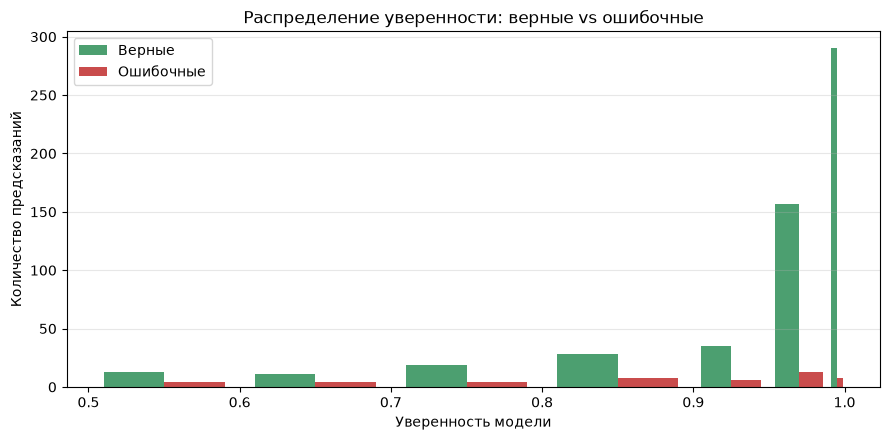

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
bins = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0]

ax.hist([df[~df['is_error']]['confidence'], df[df['is_error']]['confidence']],
        bins=bins, label=['Верные', 'Ошибочные'], color=['#4c9f70', '#c94c4c'])
ax.set_xlabel('Уверенность модели')
ax.set_ylabel('Количество предсказаний')
ax.set_title('Распределение уверенности: верные vs ошибочные')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Главная находка дня.** Больше половины ошибок сделаны с уверенностью выше 0.9 — модель ошибается уверенно.

Практическое следствие: **отсечь ошибки по порогу уверенности не получится**. Если поставить фильтр «доверяем только предсказаниям с p > 0.9», вы отбросите большую часть верных ответов и всё равно пропустите 27 из 47 ошибок. Это та самая проблема калибровки, которую мы заметили в Дне 6: три эпохи CrossEntropy загоняют логиты в крайности независимо от того, права модель или нет.

### Трудные примеры: где ошиблись все три модели

In [7]:
from error_analysis import find_hard_examples

clf_base = load_baseline()
tok_enc, encoder = load_tokenizer(), load_model()
y_pred_base = [p['prediction'] for p in predict_baseline(test_texts, clf_base, tok_enc, encoder)]

clf_tfidf, vectorizer = load_tfidf()
y_pred_tfidf = [p['prediction'] for p in predict_tfidf(test_texts, clf_tfidf, vectorizer)]

hard = find_hard_examples(df, {'baseline': y_pred_base, 'tfidf': y_pred_tfidf})

print(f'Ошиблись ВСЕ три модели: {len(hard)} примеров\n')
LABELS = {0: 'negative', 1: 'positive'}
for _, row in hard.head(10).iterrows():
    print(f'  [{LABELS[row["true_label"]]:8s}] {row["text"]}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4006.02it/s]


[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ошиблись ВСЕ три модели: 18 примеров

  [positive] that most frightening of all movies
  [negative] stifling morality tale
  [positive] to watch too many barney videos
  [negative] jay russell
  [positive] too good to be bad
  [negative] pure venality --
  [negative] there 's something fishy about a seasonal holiday kids ' movie ... that derives its moment of most convincing emotional gravity from a scene where santa gives gifts to grownups .
  [negative] a teenybopper ed wood film , replete with the pubescent scandalous innuendo and
  [negative] do n't blame eddie murphy but
  [negative] by no means a slam-dunk and sure to ultimately disappoint the action fans who will be moved to the edge of their seats by the dynamic first act , it still comes off as a touching , transcendent love story .


**Вот это и есть настоящий разбор ошибок.** 18 примеров провалили все три модели — от TF-IDF до дообученного BERT. Когда ошибаются все, дело обычно не в модели. Разберём типы:

**1. Требуется доменное знание.**
> `that most frightening of all movies` → размечено как **positive**

Для фильма ужасов «самый страшный» — это похвала. Модель видит слово `frightening` с негативной окраской в обычном языке.

**2. Идиомы и ирония.**
> `too good to be bad` → **positive**

Конструкция «слишком X, чтобы быть Y» переворачивает смысл. Здесь одновременно `good` и `bad`, и решает грамматика, а не слова.

**3. Фрагменты без тональности вообще.**
> `jay russell` → размечено как **negative**

Это просто **имя режиссёра**. В самом фрагменте тональности нет никакой — метка унаследована из контекста полной рецензии, которого модель не видит.

Причина в устройстве датасета: SST-2 собран из **фраз-фрагментов** полных рецензий (Stanford Sentiment Treebank размечает поддеревья синтаксического разбора). Часть фрагментов в отрыве от контекста не несёт тональности, но метку от родительской фразы сохраняет.

Отсюда вывод: **часть из этих 47 ошибок неустранима**. Это не потолок модели, а потолок разметки. Гнаться за F1 = 1.0 на SST-2 бессмысленно.

### Сохранение анализа

In [8]:
from error_analysis import save_analysis

observations = [
    'Ошибок 47 из 600 (7.8%): FP=27, FN=20 — перекос в сторону ложного positive.',
    'Длина текста НЕ объясняет ошибки: доля ошибок по корзинам длины 5.9-10.1% без тренда.',
    f'{stats["n_confident_errors"]} из {stats["n_errors"]} ошибок сделаны с уверенностью > 0.9 — '
    'модель переуверена, отсечь ошибки по порогу нельзя, нужна калибровка.',
    'Разрыв уверенности мал: 0.953 на верных против 0.870 на ошибочных.',
    f'{len(hard)} примеров провалили все три модели. Типы: требуется доменное знание '
    '("most frightening" = похвала для хоррора), идиомы ("too good to be bad"), '
    'и фрагменты без тональности ("jay russell" — имя режиссёра).',
    'SST-2 состоит из фраз-фрагментов рецензий, метка унаследована из контекста, '
    'которого в самом фрагменте нет. Часть ошибок неустранима — это потолок разметки.',
]

save_analysis(df, stats, 'error_analysis.txt', hard_examples=hard, observations=observations)
print(open('error_analysis.txt', encoding='utf-8').read()[:1500])

=== АНАЛИЗ ОШИБОК ===

Всего примеров: 600
Всего ошибок: 47 (7.8%)
False Positives (сказали positive, было negative): 27
False Negatives (сказали negative, было positive): 20

--- Длина текстов ---
Средняя длина ошибочных текстов: 50 симв. (9.3 слов)
Средняя длина всех текстов:      52 симв. (9.3 слов)

--- Уверенность модели ---
Средняя уверенность на верных предсказаниях:    0.953
Средняя уверенность на ошибочных предсказаниях: 0.870
Ошибок с уверенностью > 0.9: 27 из 47

=== ПРИМЕРЫ FALSE POSITIVES (сказали good, а было bad) ===

Текст: there is plenty of room for editing , and
Истинный: negative, Предсказан: positive, уверенность 0.970

Текст: fit all of pootie tang in between its punchlines
Истинный: negative, Предсказан: positive, уверенность 0.970

Текст: stifling morality tale
Истинный: negative, Предсказан: positive, уверенность 0.976

Текст: restage the whole thing
Истинный: negative, Предсказан: positive, уверенность 0.600

Текст: if routine action and jokes like this are yo

## Задача 3: Демо-приложение (Gradio)

Готово в [`app.py`](app.py), логика инференса — в [`predictor.py`](predictor.py) (общая с FastAPI).

> ⚠️ **Баг в шаблоне задания.** Там было:
> ```python
> label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
> ```
> Это карта для **трёх** классов, а наша модель обучена на SST-2 и различает **два**. С этой картой класс 1 (positive) подписывался бы как «Neutral» — то есть все позитивные отзывы демо называло бы нейтральными. Правильно:
> ```python
> LABEL_MAP = {0: 'Negative', 1: 'Positive'}
> ```

In [9]:
from predictor import predict

for text in [
    "This movie was absolutely fantastic!",
    "Terrible, waste of my time.",
    "It was okay, nothing special.",
]:
    r = predict(text)
    print(f'{r["label"]:8s} ({r["confidence"]:.1%})  <- {text}')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7688.24it/s]

Positive (99.5%)  <- This movie was absolutely fantastic!


Negative (99.4%)  <- Terrible, waste of my time.
Positive (92.2%)  <- It was okay, nothing special.


Запуск приложения:

```bash
python app.py
```

Затем откройте http://127.0.0.1:7860 — проверено, интерфейс отвечает и на фразу «This movie was absolutely fantastic!» выдаёт Positive 99%.

## Задача 4: FastAPI

Готово в [`api.py`](api.py). Помимо `/predict` добавлены `/predict_batch` и `/health`.

```bash
uvicorn api:app --reload
```

Проверим эндпоинты, не поднимая сервер, — через `TestClient`:

In [10]:
from fastapi.testclient import TestClient
from api import app as api_app

client = TestClient(api_app)

print('GET /health ->', client.get('/health').json())

r = client.post('/predict', json={'text': 'This movie was great!'})
print(f'\nPOST /predict -> {r.status_code}')
print(r.json())

r = client.post('/predict_batch', json={'texts': ['awful film', 'brilliant work']})
print(f'\nPOST /predict_batch -> {[x["label"] for x in r.json()["results"]]}')

r = client.post('/predict', json={'text': ''})
print(f'\nПустой текст -> {r.status_code} (валидация работает)')

GET /health -> {'status': 'ok'}

POST /predict -> 200
{'label': 'Positive', 'confidence': 0.9947043061256409, 'probabilities': {'Negative': 0.005295636598020792, 'Positive': 0.9947043061256409}}

POST /predict_batch -> ['Negative', 'Positive']

Пустой текст -> 422 (валидация работает)


C:\Users\Vsevolod\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


## Задача 5: README

Готов в [`README.md`](README.md) — со структурой проекта, реальными метриками всех трёх моделей, инструкциями запуска и разделом об ограничениях модели.

## Итоги недели

| День | Что сделали | Результат |
|---|---|---|
| 1 | Токенизация | Текст → subword-токены → ID |
| 2 | Эмбеддинги | CLS-вектор `[1, 768]` из `last_hidden_state` |
| 3 | Attention | 6 слоёв × 12 голов, обнаружен attention sink |
| 4 | Baseline | F1 = 0.8630 на замороженных признаках |
| 5 | Fine-tuning | F1 = 0.9204, обучено 67 млн параметров |
| 6 | Сравнение | TF-IDF 0.72 → заморожен 0.86 → дообучен 0.92 |
| 7 | Анализ ошибок | 47 ошибок, из них 18 неустранимых |

### Три вывода, которые стоит унести

**1. Baseline обязателен.** Без TF-IDF (0.72) казалось бы, что 0.86 у замороженной модели — скромный результат. Без замороженного baseline (0.86) казалось бы, что 0.92 у fine-tuning — огромная победа. Цифра имеет смысл только в сравнении.

**2. Высокая уверенность ≠ правота.** 27 из 47 ошибок сделаны с уверенностью > 0.9. Софтмакс после обучения на CrossEntropy — это не вероятность в статистическом смысле, и полагаться на неё как на оценку риска без калибровки нельзя.

**3. Часть ошибок — не про модель.** 18 примеров провалили все три подхода, включая фрагменты вроде `jay russell` (имя режиссёра, размечено как negative). Прежде чем крутить гиперпараметры ради последних процентов, стоит посмотреть на сами ошибки — иногда там потолок разметки, а не модели.